# Task 5 — Strategy Backtesting

**GMF Investments · Week 9**

Validate the Task 4 recommendation by simulating it on held-out data against a
**static 60% SPY / 40% BND benchmark**.

- **Window:** the final year of the dataset (Jun 2025 → Jun 2026) — entirely
  outside the 2015–2024 model-training period.
- **Strategy:** hold the Task 4 max-Sharpe weights (buy & hold), plus a monthly
  rebalanced variant.
- **Metrics:** total return, annualized return, Sharpe ratio, max drawdown.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import config, backtesting as bt

sns.set_theme(style="whitegrid")
FIG_DIR = ROOT / "reports" / "figures"

returns = pd.read_csv(config.PROCESSED_DIR / 'daily_returns.csv', index_col=0, parse_dates=True)
weights = pd.read_csv(config.PROCESSED_DIR / 'optimal_weights.csv', index_col=0)['weight']

# Final year of the dataset, held out from model training (train ended 2024-12-31)
bt_end = returns.index.max()
bt_start = bt_end - pd.DateOffset(years=1)
bt_returns = returns.loc[bt_start:bt_end]
print(f'Backtest window: {bt_returns.index.min().date()} -> {bt_returns.index.max().date()} ({len(bt_returns)} days)')
print('Strategy weights (Task 4 max Sharpe):', weights.round(4).to_dict())
print('Benchmark weights:', config.BENCHMARK_WEIGHTS)

Backtest window: 2025-06-30 -> 2026-06-29 (251 days)
Strategy weights (Task 4 max Sharpe): {'TSLA': 0.0, 'BND': 0.0, 'SPY': 1.0}
Benchmark weights: {'SPY': 0.6, 'BND': 0.4}


## 1. Simulate Strategy vs Benchmark

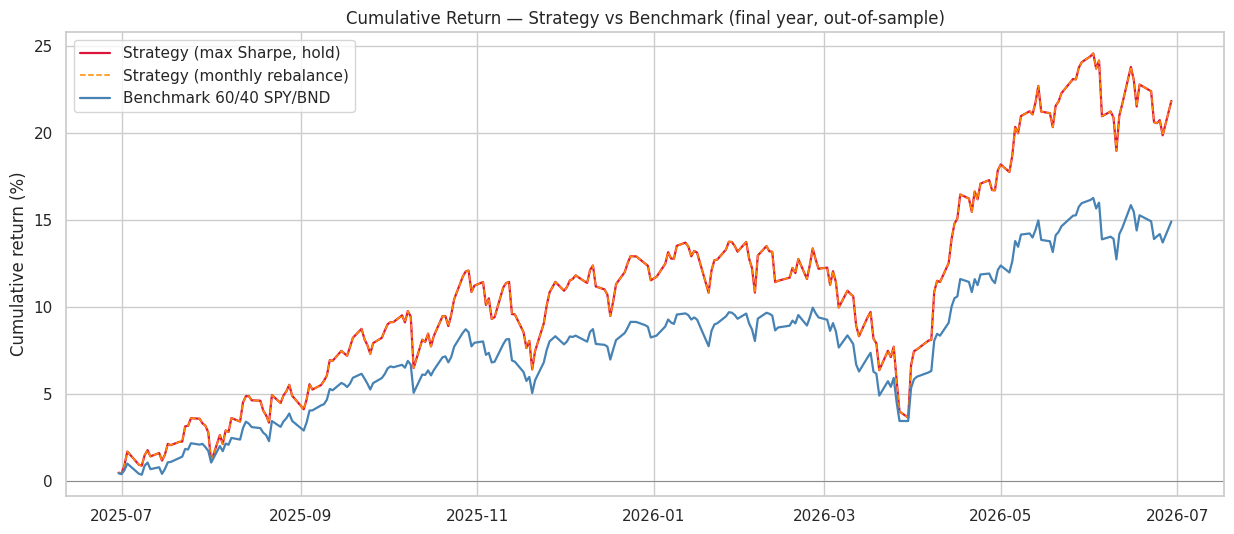

In [2]:
strategy = bt.run_backtest(bt_returns, weights)                       # buy & hold
strategy_reb = bt.run_backtest(bt_returns, weights, rebalance='ME')   # monthly rebalance
benchmark = bt.benchmark_portfolio(bt_returns)                        # 60/40 SPY/BND

fig, ax = plt.subplots(figsize=(12.5, 5.5))
ax.plot(strategy.index, 100 * (strategy - 1), label='Strategy (max Sharpe, hold)', color='crimson', lw=1.6)
ax.plot(strategy_reb.index, 100 * (strategy_reb - 1), label='Strategy (monthly rebalance)', color='darkorange', lw=1.1, ls='--')
ax.plot(benchmark.index, 100 * (benchmark - 1), label='Benchmark 60/40 SPY/BND', color='steelblue', lw=1.6)
ax.axhline(0, color='grey', lw=0.6)
ax.set_title('Cumulative Return — Strategy vs Benchmark (final year, out-of-sample)')
ax.set_ylabel('Cumulative return (%)'); ax.legend()
fig.tight_layout(); fig.savefig(FIG_DIR / '20_backtest_cumulative.png', dpi=120)
plt.show()

## 2. Performance Metrics

In [3]:
metrics = pd.DataFrame({
    'Strategy (hold)': bt.performance_metrics(strategy),
    'Strategy (monthly rebal.)': bt.performance_metrics(strategy_reb),
    'Benchmark 60/40': bt.performance_metrics(benchmark),
}).T
metrics.to_csv(config.PROCESSED_DIR / 'backtest_metrics.csv')
display(metrics.style.format({
    'total_return': '{:.2%}', 'annualized_return': '{:.2%}',
    'annualized_volatility': '{:.2%}', 'sharpe': '{:.2f}', 'max_drawdown': '{:.2%}'
}))

,total_return,annualized_return,annualized_volatility,sharpe,max_drawdown
Strategy (hold),21.26%,21.45%,12.57%,1.55,-8.88%
Strategy (monthly rebal.),21.26%,21.45%,12.57%,1.55,-8.88%
Benchmark 60/40,14.41%,14.53%,8.31%,1.51,-5.92%


## 3. Conclusion & Limitations

**Verdict: the strategy outperformed the benchmark on absolute return, roughly tied on risk-adjusted return, and lost on drawdown.** Over the
out-of-sample year the max-Sharpe portfolio (100% SPY) returned **+21.3%**
vs the 60/40's **+14.4%**, with Sharpe **1.55 vs 1.51** — statistically a
wash — while suffering a deeper maximum drawdown (**−8.9% vs −5.9%**) on
half again the volatility (12.6% vs 8.3%). In plain terms: the model-driven
tilt away from TSLA and bonds bought more return by taking proportionally
more equity risk, not by finding genuine alpha. The two strategy variants
coincide because a single-asset portfolio has nothing to rebalance.

**What this backtest can and cannot say.**
- **One window, one regime.** A single year cannot establish edge; the
  result is dominated by 2025–26 being a good year for SPY. The near-equal
  Sharpe ratios show the *risk-adjusted* edge is negligible.
- **Static view.** The TSLA forecast was generated once; a live process
  would refresh the view (and weights) monthly as data arrives.
- **Frictionless assumptions.** No transaction costs, slippage, taxes, or
  dividend-timing effects are modeled (both portfolios benefit equally).
- **Concentration.** The 100%-SPY corner solution inherits none of the
  diversification MPT is meant to deliver — its deeper drawdown is the
  visible cost. A tempered view (Black-Litterman blending, weight caps)
  would produce a more robust portfolio.

**Overall,** the pipeline — forecast → view → optimizer → out-of-sample test
— is validated and the strategy was *viable* this year, but the honest
takeaway from Tasks 2–3 (a random walk was the best one-step forecaster;
CIs fan out fast) argues for using model views to **tilt, not dictate,**
allocations, and for judging success by Sharpe and drawdown rather than
raw return.